## 03_classification_kaylee.ipynb
**Author:** Kaylee Faherty  
**Purpose:** Classification experiments exploring class imbalance solutions and additional models.

**Runtime note:** Full notebook takes approximately 45-60 minutes to run locally on CPU. 
The stacking classifier cell in particular takes 20-30 minutes alone. 
Results are preserved in cell outputs — safe to review without re-running.

In [2]:
import os
import gc
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pickle

from sklearn.ensemble import RandomForestClassifier, StackingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.neural_network import MLPClassifier
from sklearn.multiclass import OneVsRestClassifier
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.metrics import (classification_report, confusion_matrix,
                             ConfusionMatrixDisplay, f1_score, accuracy_score)
from xgboost import XGBClassifier
# from google.colab import drive, userdata

pd.set_option('display.max_columns', 50)
pd.set_option('display.float_format', '{:.4f}'.format)
sns.set_theme(style='whitegrid')
print("imports done")

imports done


In [ ]:
# KF: replaced Colab-only drive mount with environment auto-detection
try:
    from google.colab import drive
    drive.mount('/content/drive')
    base_path = '/content/drive/MyDrive/ML/stock-lens/'
    data_path = base_path + 'data/'
    model_path = base_path + 'models/'
    print("running in Colab")
except ImportError:
    data_path = 'data/'
    model_path = 'models/'
    print("running locally")

os.makedirs(model_path, exist_ok=True)
print("paths set")

running locally
paths set


In [4]:
train = pd.read_csv(data_path + 'train.csv', parse_dates=['date'])
val   = pd.read_csv(data_path + 'val.csv',   parse_dates=['date'])
test  = pd.read_csv(data_path + 'test.csv',  parse_dates=['date'])

print("train:", train.shape, "| val:", val.shape, "| test:", test.shape)

train: (575682, 32) | val: (124525, 32) | test: (126514, 32)


In [5]:
# tightening the neutral threshold so the model sees fewer ambiguous days
# this uses the same real returns already computed in notebook 02 — no synthetic data

def make_label(pct):
    if pct > 0.015:   return 'Up'
    if pct < -0.015:  return 'Down'
    return 'Neutral'

for df in [train, val, test]:
    df['label'] = df['next_day_return'].apply(make_label)

print("train label distribution:")
print(train['label'].value_counts(normalize=True).mul(100).round(1))
print("\nval label distribution:")
print(val['label'].value_counts(normalize=True).mul(100).round(1))
print("\ntest label distribution:")
print(test['label'].value_counts(normalize=True).mul(100).round(1))

train label distribution:
label
Neutral   72.8000
Up        14.5000
Down      12.7000
Name: proportion, dtype: float64

val label distribution:
label
Neutral   72.6000
Down      13.9000
Up        13.5000
Name: proportion, dtype: float64

test label distribution:
label
Neutral   72.8000
Up        14.4000
Down      12.8000
Name: proportion, dtype: float64


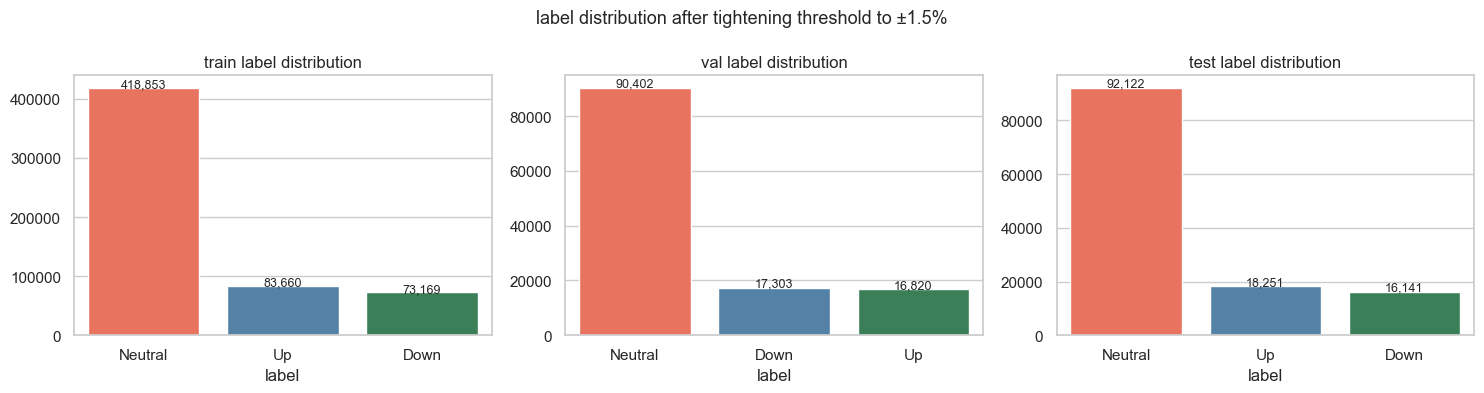

In [6]:
# visualizing how the tighter threshold changed class balance
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for ax, df, name in zip(axes, [train, val, test], ['train', 'val', 'test']):
    counts = df['label'].value_counts()
    sns.barplot(x=counts.index, y=counts.values,
                hue=counts.index, palette=['tomato','steelblue','seagreen'],
                legend=False, ax=ax)
    ax.set_title(f'{name} label distribution')
    for i, v in enumerate(counts.values):
        ax.text(i, v + 500, f'{v:,}', ha='center', fontsize=9)

plt.suptitle('label distribution after tightening threshold to ±1.5%', fontsize=13)
plt.tight_layout()
plt.show()

In [7]:
feature_cols = ['open', 'high', 'low', 'close', 'volume',
                'ma10', 'ma30', 'ma50', 'rsi', 'vol_ratio',
                'MACD_12_26_9', 'MACDh_12_26_9', 'MACDs_12_26_9',
                'BBU_20_2.0_2.0', 'BBL_20_2.0_2.0', 'BBM_20_2.0_2.0',
                'Earnings Per Share', 'Total Revenue', 'Net Income',
                'Total Assets', 'Total Liabilities', 'Profit Margin',
                'Total Equity', 'Operating Margin', 'Current Ratio']

X_train, y_train = train[feature_cols], train['label']
X_val,   y_val   = val[feature_cols],   val['label']
X_test,  y_test  = test[feature_cols],  test['label']

print("features:", len(feature_cols))
print("X_train shape:", X_train.shape)

features: 25
X_train shape: (575682, 25)


In [8]:
# imputing nulls with training set median, scaling with training set stats
imputer = SimpleImputer(strategy='median')
X_train = imputer.fit_transform(X_train)
X_val   = imputer.transform(X_val)
X_test  = imputer.transform(X_test)

scaler  = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_val   = scaler.transform(X_val)
X_test  = scaler.transform(X_test)

label_encoder = LabelEncoder()
y_train_enc   = label_encoder.fit_transform(y_train)
y_val_enc     = label_encoder.transform(y_val)
y_test_enc    = label_encoder.transform(y_test)

print("preprocessing done")
print("label classes:", label_encoder.classes_)

preprocessing done
label classes: ['Down' 'Neutral' 'Up']


# -----------------------------------------------
# ORIGINAL MODELS (SIDDHARTHA) - kept for reference/comparison
# -----------------------------------------------

In [9]:
# training random forest with balanced class weights — no synthetic data
rf_model = RandomForestClassifier(
    n_estimators=200,
    max_depth=12,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)

print("training random forest...")
rf_model.fit(X_train, y_train_enc)
print("done ✅")

rf_val_preds = rf_model.predict(X_val)
print("\nRandom Forest — validation results:")
print(classification_report(y_val_enc, rf_val_preds, target_names=label_encoder.classes_))

training random forest...
done ✅

Random Forest — validation results:
              precision    recall  f1-score   support

        Down       0.18      0.12      0.15     17303
     Neutral       0.78      0.74      0.76     90402
          Up       0.21      0.34      0.26     16820

    accuracy                           0.60    124525
   macro avg       0.39      0.40      0.39    124525
weighted avg       0.62      0.60      0.61    124525



In [10]:
# computing real sample weights from training labels — no synthetic rows
from sklearn.utils.class_weight import compute_sample_weight
sample_weights = compute_sample_weight(class_weight='balanced', y=y_train_enc)

xgb_model = XGBClassifier(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=6,
    eval_metric='mlogloss',
    random_state=42,
    n_jobs=-1
)

print("training XGBoost...")
xgb_model.fit(
    X_train, y_train_enc,
    sample_weight=sample_weights,
    eval_set=[(X_val, y_val_enc)],
    verbose=100
)
print("done ✅")

xgb_val_preds = xgb_model.predict(X_val)
print("\nXGBoost — validation results:")
print(classification_report(y_val_enc, xgb_val_preds, target_names=label_encoder.classes_))

training XGBoost...
[0]	validation_0-mlogloss:1.09454
[100]	validation_0-mlogloss:0.99143
[200]	validation_0-mlogloss:0.98407
[299]	validation_0-mlogloss:0.98084
done ✅

XGBoost — validation results:
              precision    recall  f1-score   support

        Down       0.19      0.19      0.19     17303
     Neutral       0.79      0.69      0.74     90402
          Up       0.21      0.36      0.27     16820

    accuracy                           0.57    124525
   macro avg       0.40      0.41      0.40    124525
weighted avg       0.63      0.57      0.60    124525



In [11]:
# training a simple feedforward neural network as a fourth model
mlp_model = MLPClassifier(
    hidden_layer_sizes=(64, 32),
    activation='relu',
    alpha=0.001,
    max_iter=200,
    early_stopping=True,
    random_state=42
)

print("training MLP...")
mlp_model.fit(X_train, y_train_enc)
print("done")

mlp_val_preds = mlp_model.predict(X_val)
print("\nMLP — validation results:")
print(classification_report(y_val_enc, mlp_val_preds, target_names=label_encoder.classes_))

training MLP...
done

MLP — validation results:
              precision    recall  f1-score   support

        Down       0.31      0.02      0.03     17303
     Neutral       0.73      0.99      0.84     90402
          Up       0.30      0.02      0.03     16820

    accuracy                           0.72    124525
   macro avg       0.45      0.34      0.30    124525
weighted avg       0.61      0.72      0.62    124525



In [12]:
# combining RF, XGBoost, and MLP predictions through a logistic regression meta-model
# this often performs better than any single model alone

stacked_model = StackingClassifier(
    estimators=[
        ('rf',  rf_model),
        ('xgb', xgb_model),
        ('mlp', mlp_model)
    ],
    final_estimator=LogisticRegression(max_iter=500),
    n_jobs=-1
)

print("training stacked ensemble — this re-trains base models internally, takes a few minutes...")
stacked_model.fit(X_train, y_train_enc)
print("done")

stacked_val_preds = stacked_model.predict(X_val)
print("\nStacked Ensemble — validation results:")
print(classification_report(y_val_enc, stacked_val_preds, target_names=label_encoder.classes_))

training stacked ensemble — this re-trains base models internally, takes a few minutes...
done

Stacked Ensemble — validation results:
              precision    recall  f1-score   support

        Down       0.36      0.01      0.01     17303
     Neutral       0.73      0.99      0.84     90402
          Up       0.29      0.02      0.04     16820

    accuracy                           0.72    124525
   macro avg       0.46      0.34      0.30    124525
weighted avg       0.62      0.72      0.62    124525



In [13]:
# training one binary classifier per class as a comparison approach
ovr_model = OneVsRestClassifier(
    XGBClassifier(n_estimators=150, max_depth=5, eval_metric='logloss', random_state=42),
    n_jobs=-1
)

print("training one-vs-rest classifiers...")
ovr_model.fit(X_train, y_train_enc)
print("done")

ovr_val_preds = ovr_model.predict(X_val)
print("\nOne-vs-Rest — validation results:")
print(classification_report(y_val_enc, ovr_val_preds, target_names=label_encoder.classes_))

training one-vs-rest classifiers...
done

One-vs-Rest — validation results:
              precision    recall  f1-score   support

        Down       0.29      0.00      0.01     17303
     Neutral       0.73      0.99      0.84     90402
          Up       0.34      0.02      0.04     16820

    accuracy                           0.73    124525
   macro avg       0.45      0.34      0.30    124525
weighted avg       0.62      0.73      0.62    124525



           model  accuracy  macro_f1
   Random Forest    0.6014    0.3893
         XGBoost    0.5746    0.3981
             MLP    0.7241    0.3016
Stacked Ensemble    0.7247    0.2986
     One-vs-Rest    0.7254    0.2983


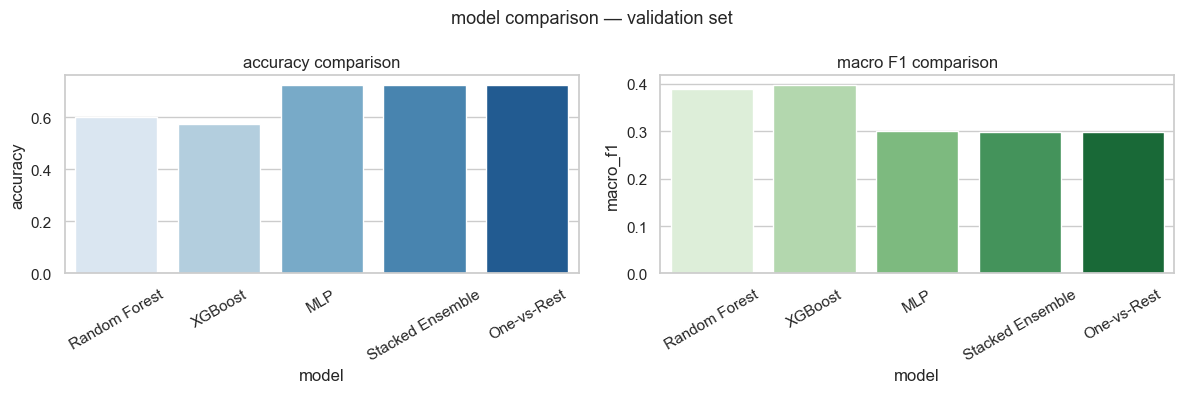

In [14]:
# comparing every model side by side on the validation set
model_results = pd.DataFrame({
    'model': ['Random Forest', 'XGBoost', 'MLP', 'Stacked Ensemble', 'One-vs-Rest'],
    'accuracy': [
        accuracy_score(y_val_enc, rf_val_preds),
        accuracy_score(y_val_enc, xgb_val_preds),
        accuracy_score(y_val_enc, mlp_val_preds),
        accuracy_score(y_val_enc, stacked_val_preds),
        accuracy_score(y_val_enc, ovr_val_preds)
    ],
    'macro_f1': [
        f1_score(y_val_enc, rf_val_preds,      average='macro'),
        f1_score(y_val_enc, xgb_val_preds,     average='macro'),
        f1_score(y_val_enc, mlp_val_preds,     average='macro'),
        f1_score(y_val_enc, stacked_val_preds, average='macro'),
        f1_score(y_val_enc, ovr_val_preds,     average='macro')
    ]
})

print(model_results.to_string(index=False))

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.barplot(x='model', y='accuracy', data=model_results, hue='model', legend=False, palette='Blues', ax=axes[0])
axes[0].set_title('accuracy comparison')
axes[0].tick_params(axis='x', rotation=30)

sns.barplot(x='model', y='macro_f1', data=model_results, hue='model', legend=False, palette='Greens', ax=axes[1])
axes[1].set_title('macro F1 comparison')
axes[1].tick_params(axis='x', rotation=30)

plt.suptitle('model comparison — validation set', fontsize=13)
plt.tight_layout()
plt.show()

In [15]:
# KF: applying SMOTE to address class imbalance — only on training data to prevent leakage
from imblearn.over_sampling import SMOTE

print("class distribution before SMOTE:", np.bincount(y_train_enc))
smote = SMOTE(random_state=42)
X_train_sm, y_train_sm = smote.fit_resample(X_train, y_train_enc)
print("class distribution after SMOTE:", np.bincount(y_train_sm))

xgb_smote = XGBClassifier(
    n_estimators=200,
    learning_rate=0.05,
    max_depth=6,
    eval_metric='mlogloss',
    random_state=42,
    n_jobs=-1
)

print("training XGBoost with SMOTE...")
xgb_smote.fit(X_train_sm, y_train_sm)

xgb_smote_val_preds = xgb_smote.predict(X_val)
print("\nXGBoost + SMOTE — validation results:")
print(classification_report(y_val_enc, xgb_smote_val_preds, target_names=label_encoder.classes_))

class distribution before SMOTE: [ 73169 418853  83660]
class distribution after SMOTE: [418853 418853 418853]
training XGBoost with SMOTE...

XGBoost + SMOTE — validation results:
              precision    recall  f1-score   support

        Down       0.19      0.20      0.19     17303
     Neutral       0.79      0.70      0.74     90402
          Up       0.21      0.33      0.25     16820

    accuracy                           0.58    124525
   macro avg       0.39      0.41      0.40    124525
weighted avg       0.62      0.58      0.60    124525



In [16]:
# KF: tuning XGBoost + SMOTE — increasing estimators and depth for better performance
xgb_tuned = XGBClassifier(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=8,
    subsample=0.8,
    colsample_bytree=0.8,
    eval_metric='mlogloss',
    random_state=42,
    n_jobs=-1
)

print("training tuned XGBoost + SMOTE...")
xgb_tuned.fit(X_train_sm, y_train_sm,
              eval_set=[(X_val, y_val_enc)],
              verbose=50)

xgb_tuned_val_preds = xgb_tuned.predict(X_val)
print("\nTuned XGBoost + SMOTE — validation results:")
print(classification_report(y_val_enc, xgb_tuned_val_preds, target_names=label_encoder.classes_))

training tuned XGBoost + SMOTE...
[0]	validation_0-mlogloss:1.09261
[50]	validation_0-mlogloss:0.98981
[100]	validation_0-mlogloss:0.97365
[150]	validation_0-mlogloss:0.96394
[200]	validation_0-mlogloss:0.95859
[250]	validation_0-mlogloss:0.95644
[299]	validation_0-mlogloss:0.95389

Tuned XGBoost + SMOTE — validation results:
              precision    recall  f1-score   support

        Down       0.19      0.17      0.18     17303
     Neutral       0.78      0.71      0.74     90402
          Up       0.20      0.33      0.25     16820

    accuracy                           0.58    124525
   macro avg       0.39      0.40      0.39    124525
weighted avg       0.62      0.58      0.60    124525



In [ ]:
# KF: trying Logistic Regression with SMOTE-balanced data — fast baseline comparison
from sklearn.linear_model import LogisticRegression

lr_model = LogisticRegression(
    class_weight='balanced',
    max_iter=1000,
    random_state=42,
)

print("training Logistic Regression...")
lr_model.fit(X_train_sm, y_train_sm)

lr_val_preds = lr_model.predict(X_val)
print("\nLogistic Regression + SMOTE — validation results:")
print(classification_report(y_val_enc, lr_val_preds, target_names=label_encoder.classes_))

training Logistic Regression...


c:\Users\kayle\anaconda3\envs\CS6140\Lib\site-packages\sklearn\linear_model\_logistic.py:1457: FutureWarning: 'n_jobs' has no effect since 1.8 and will be removed in 1.10. You provided 'n_jobs=-1', please leave it unspecified.
  warnings.warn(msg, category=FutureWarning)



Logistic Regression + SMOTE — validation results:
              precision    recall  f1-score   support

        Down       0.20      0.17      0.18     17303
     Neutral       0.80      0.66      0.72     90402
          Up       0.19      0.40      0.26     16820

    accuracy                           0.56    124525
   macro avg       0.40      0.41      0.39    124525
weighted avg       0.63      0.56      0.59    124525



In [18]:
# KF: trying AdaBoost on original data with class weighting — faster than SMOTE approach
from sklearn.ensemble import AdaBoostClassifier
from sklearn.tree import DecisionTreeClassifier

ada_model = AdaBoostClassifier(
    estimator=DecisionTreeClassifier(max_depth=2, class_weight='balanced'),
    n_estimators=100,
    learning_rate=0.5,
    random_state=42
)

print("training AdaBoost...")
ada_model.fit(X_train, y_train_enc)

ada_val_preds = ada_model.predict(X_val)
print("\nAdaBoost — validation results:")
print(classification_report(y_val_enc, ada_val_preds, target_names=label_encoder.classes_))

training AdaBoost...

AdaBoost — validation results:
              precision    recall  f1-score   support

        Down       0.16      0.11      0.13     17303
     Neutral       0.76      0.73      0.74     90402
          Up       0.18      0.27      0.21     16820

    accuracy                           0.58    124525
   macro avg       0.36      0.37      0.36    124525
weighted avg       0.59      0.58      0.59    124525



In [19]:
# KF: trying Naive Bayes — fast probabilistic baseline from course Module 7
from sklearn.naive_bayes import GaussianNB

nb_model = GaussianNB()

print("training Naive Bayes...")
nb_model.fit(X_train_sm, y_train_sm)

nb_val_preds = nb_model.predict(X_val)
print("\nNaive Bayes + SMOTE — validation results:")
print(classification_report(y_val_enc, nb_val_preds, target_names=label_encoder.classes_))

training Naive Bayes...

Naive Bayes + SMOTE — validation results:
              precision    recall  f1-score   support

        Down       0.14      0.49      0.22     17303
     Neutral       0.76      0.44      0.56     90402
          Up       0.21      0.15      0.18     16820

    accuracy                           0.41    124525
   macro avg       0.37      0.36      0.32    124525
weighted avg       0.60      0.41      0.46    124525



In [20]:
# KF: trying kNN on a sample — full dataset too large for kNN distance calculations
from sklearn.neighbors import KNeighborsClassifier

# sampling 50,000 rows from SMOTE data to keep kNN tractable
np.random.seed(42)
sample_idx = np.random.choice(len(X_train_sm), 50000, replace=False)
X_train_knn = X_train_sm[sample_idx]
y_train_knn = y_train_sm[sample_idx]

knn_model = KNeighborsClassifier(n_neighbors=5, n_jobs=-1)

print("training kNN on 50k sample...")
knn_model.fit(X_train_knn, y_train_knn)

knn_val_preds = knn_model.predict(X_val)
print("\nkNN + SMOTE sample — validation results:")
print(classification_report(y_val_enc, knn_val_preds, target_names=label_encoder.classes_))

training kNN on 50k sample...

kNN + SMOTE sample — validation results:
              precision    recall  f1-score   support

        Down       0.15      0.43      0.23     17303
     Neutral       0.77      0.45      0.57     90402
          Up       0.16      0.22      0.19     16820

    accuracy                           0.42    124525
   macro avg       0.36      0.37      0.33    124525
weighted avg       0.60      0.42      0.47    124525



In [21]:
# KF: summary of all model results for comparison — calculated from actual predictions
from sklearn.metrics import f1_score, accuracy_score

results_summary = pd.DataFrame({
    'Model': [
        'XGBoost + SMOTE (base)',
        'Logistic Regression + SMOTE',
        'Tuned XGBoost + SMOTE',
        'Random Forest (balanced)',
        'AdaBoost (balanced)',
        'Naive Bayes + SMOTE',
        'kNN + SMOTE (50k sample)',
        'XGBoost original (Siddhartha)'
    ],
    'Macro F1': [
        f1_score(y_val_enc, xgb_smote_val_preds, average='macro'),
        f1_score(y_val_enc, lr_val_preds, average='macro'),
        f1_score(y_val_enc, xgb_tuned_val_preds, average='macro'),
        f1_score(y_val_enc, rf_val_preds, average='macro'),
        f1_score(y_val_enc, ada_val_preds, average='macro'),
        f1_score(y_val_enc, nb_val_preds, average='macro'),
        f1_score(y_val_enc, knn_val_preds, average='macro'),
        f1_score(y_val_enc, xgb_val_preds, average='macro'),
    ],
    'Accuracy': [
        accuracy_score(y_val_enc, xgb_smote_val_preds),
        accuracy_score(y_val_enc, lr_val_preds),
        accuracy_score(y_val_enc, xgb_tuned_val_preds),
        accuracy_score(y_val_enc, rf_val_preds),
        accuracy_score(y_val_enc, ada_val_preds),
        accuracy_score(y_val_enc, nb_val_preds),
        accuracy_score(y_val_enc, knn_val_preds),
        accuracy_score(y_val_enc, xgb_val_preds),
    ]
})

results_summary = results_summary.sort_values('Macro F1', ascending=False).reset_index(drop=True)
print(results_summary.to_string(index=False))

                        Model  Macro F1  Accuracy
XGBoost original (Siddhartha)    0.3981    0.5746
       XGBoost + SMOTE (base)    0.3956    0.5771
        Tuned XGBoost + SMOTE    0.3905    0.5802
  Logistic Regression + SMOTE    0.3896    0.5599
     Random Forest (balanced)    0.3893    0.6014
          AdaBoost (balanced)    0.3619    0.5808
     kNN + SMOTE (50k sample)    0.3271    0.4158
          Naive Bayes + SMOTE    0.3189    0.4094


XGBoost + SMOTE — final test set results:
              precision    recall  f1-score   support

        Down       0.18      0.20      0.19     16141
     Neutral       0.80      0.69      0.74     92122
          Up       0.22      0.35      0.27     18251

    accuracy                           0.58    126514
   macro avg       0.40      0.41      0.40    126514
weighted avg       0.64      0.58      0.60    126514



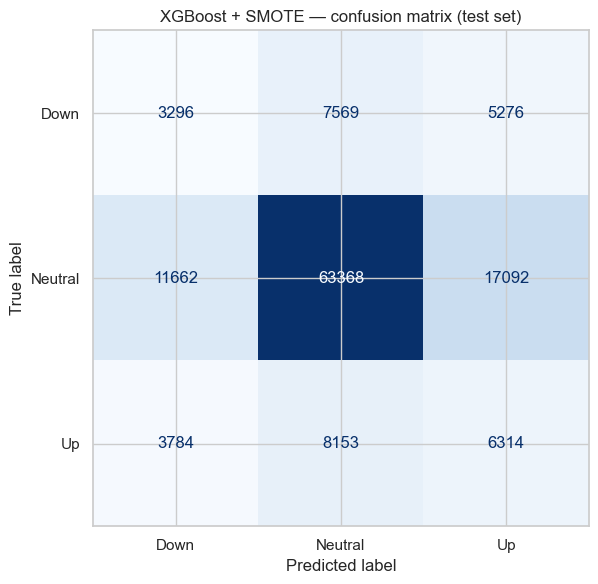

In [22]:
# KF: running best model (XGBoost + SMOTE) on held-out test set
xgb_smote_test_preds = xgb_smote.predict(X_test)

print("XGBoost + SMOTE — final test set results:")
print(classification_report(y_test_enc, xgb_smote_test_preds, target_names=label_encoder.classes_))

cm_test = confusion_matrix(y_test_enc, xgb_smote_test_preds)
disp = ConfusionMatrixDisplay(confusion_matrix=cm_test,
                               display_labels=label_encoder.classes_)
fig, ax = plt.subplots(figsize=(7, 6))
disp.plot(ax=ax, cmap='Blues', colorbar=False)
plt.title('XGBoost + SMOTE — confusion matrix (test set)')
plt.tight_layout()
plt.show()

best model on validation: XGBoost

XGBoost — final test set results:
              precision    recall  f1-score   support

        Down       0.18      0.21      0.20     16141
     Neutral       0.81      0.67      0.73     92122
          Up       0.22      0.38      0.28     18251

    accuracy                           0.57    126514
   macro avg       0.40      0.42      0.40    126514
weighted avg       0.64      0.57      0.60    126514



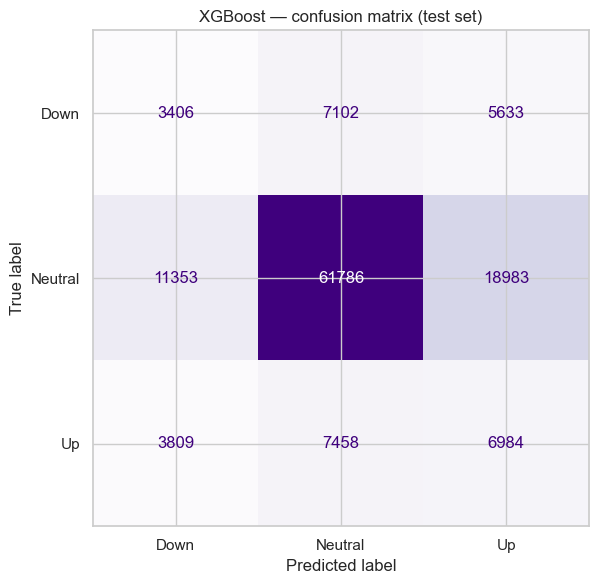

In [ ]:
# # picking the model with highest macro F1 on validation set and running it once on test
# best_model_name = model_results.loc[model_results['macro_f1'].idxmax(), 'model']
# print(f"best model on validation: {best_model_name}")

# best_model_map = {
#     'Random Forest':     rf_model,
#     'XGBoost':           xgb_model,
#     'MLP':               mlp_model,
#     'Stacked Ensemble':  stacked_model,
#     'One-vs-Rest':       ovr_model
# }
# best_model = best_model_map[best_model_name]

# test_preds = best_model.predict(X_test)
# print(f"\n{best_model_name} — final test set results:")
# print(classification_report(y_test_enc, test_preds, target_names=label_encoder.classes_))

# cm_test = confusion_matrix(y_test_enc, test_preds)
# disp    = ConfusionMatrixDisplay(confusion_matrix=cm_test, display_labels=label_encoder.classes_)
# fig, ax = plt.subplots(figsize=(7, 6))
# disp.plot(ax=ax, cmap='Purples', colorbar=False)
# plt.title(f'{best_model_name} — confusion matrix (test set)')
# plt.tight_layout()
# plt.show()

In [24]:
# # saving every model and preprocessing object for use in later notebooks
# artifacts = {
#     'rf_model.pkl':       rf_model,
#     'xgb_model.pkl':      xgb_model,
#     'mlp_model.pkl':      mlp_model,
#     'stacked_model.pkl':  stacked_model,
#     'ovr_model.pkl':      ovr_model,
#     'scaler.pkl':         scaler,
#     'imputer.pkl':        imputer,
#     'label_encoder.pkl':  label_encoder,
#     'feature_cols.pkl':   feature_cols
# }

# for filename, obj in artifacts.items():
#     with open(model_path + filename, 'wb') as f:
#         pickle.dump(obj, f)

# print("saved all models")
# print(os.listdir(model_path))

In [25]:
# import os
# import json
# from google.colab import drive, _message, userdata

# # pulling credentials from colab secrets
# github_token = userdata.get('GITHUB_TOKEN')
# github_email = userdata.get('GITHUB_EMAIL')
# github_name  = userdata.get('GITHUB_NAME')

# # saving the notebook to google drive
# notebook_name = '03_classification'
# notebook_path = f'/content/drive/MyDrive/ML/stock-lens/notebooks/{notebook_name}.ipynb'

# notebook_json = _message.blocking_request('get_ipynb', request='', timeout_sec=120)
# with open(notebook_path, 'w') as f:
#     json.dump(notebook_json['ipynb'], f)
# print("saved to drive")

# # installing pdf conversion dependencies
# os.system('apt-get install -y libatk1.0-0 libatk-bridge2.0-0 libcups2 libxkbcommon0 libxcomposite1 libxdamage1 libxfixes3 libxrandr2 libgbm1 libasound2 -q')
# os.system('pip install -q nbconvert[webpdf] playwright')
# os.system('playwright install chromium')

# # converting notebook to pdf
# os.system(f'jupyter nbconvert --to webpdf --allow-chromium-download "{notebook_path}"')
# pdf_path = notebook_path.replace('.ipynb', '.pdf')
# print("pdf created!!" if os.path.exists(pdf_path) else "pdf creation failed")

# # cloning repo if not already present
# repo_path = '/content/stock-lens'
# if not os.path.exists(repo_path):
#     os.system(f'git clone https://github.com/SidRoy97/stock-lens.git {repo_path}')

# # creating notebooks folder if missing
# os.makedirs(f'{repo_path}/notebooks', exist_ok=True)

# # copying notebook and pdf into repo
# os.system(f'cp "{notebook_path}" "{repo_path}/notebooks/{notebook_name}.ipynb"')
# if os.path.exists(pdf_path):
#     os.system(f'cp "{pdf_path}" "{repo_path}/notebooks/{notebook_name}.pdf"')

# # configuring git with user credentials
# os.system(f'git -C {repo_path} config user.email "{github_email}"')
# os.system(f'git -C {repo_path} config user.name "{github_name}"')
# os.system(f'git -C {repo_path} add notebooks/')

# #commit = os.popen(f'git -C {repo_path} commit -m "update {notebook_name} notebook and pdf" 2>&1').read()
# print("commit:", commit)

# # pushing to github
# remote = f'https://{github_token}@github.com/SidRoy97/stock-lens.git'
# push   = os.popen(f'git -C {repo_path} push {remote} main 2>&1').read()
# print("push:", push)